In [5]:
from sklearn.datasets import fetch_california_housing

from CH15.Quince_04_TimeSeriesSimpleLeanrRegression import linear_regression

In [6]:
california = fetch_california_housing()

In [7]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
#Get the data and target attributes to get an NumPy arrays containing the samples and their target values

In [9]:
california.data.shape           #(samples, 8 features)

(20640, 8)

In [10]:
california.target.shape         #Return the target values -> the median house values, which we want to predict

(20640,)

In [11]:
california.feature_names        #Return the names that correspond to each column in the data array

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [12]:
#Explore the data further

In [13]:
import pandas as pd

In [14]:
pd.set_option('display.precision', 4)               #Maximum number of digitis to display to the right of each decimal point
pd.set_option('display.max_columns', 9)             #The maximum number of columns to display when you output the DataFrame's string representation
pd.set_option('display.width', None)                #Auto-detect the display width when formatting string representations

In [15]:
california_df = pd.DataFrame(california.data, columns = california.feature_names)

In [16]:
california_df['MedHouseValue'] = pd.Series(california.target)

In [17]:
california_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.0455,1.1333,845.0,2.5606,39.48,-121.09,0.781
20636,2.5568,18.0,6.1140,1.3158,356.0,3.1228,39.49,-121.21,0.771
20637,1.7000,17.0,5.2055,1.1201,1007.0,2.3256,39.43,-121.22,0.923
20638,1.8672,18.0,5.3295,1.1719,741.0,2.1232,39.43,-121.32,0.847


In [18]:
california_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [19]:
#Randomly select 10% of samples for graphing purposes

In [20]:
sample_df = california_df.sample(
    frac=0.1,                   #Specifies the fraction of the data to select (10%)
    random_state=17             #Seed the random number generator for reproducibility purposes
)

In [21]:
#Graphing the data

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
sns.set(font_scale=2)           #Scale each diagram'f fonts to two times their default size
sns.set_style('whitegrid')

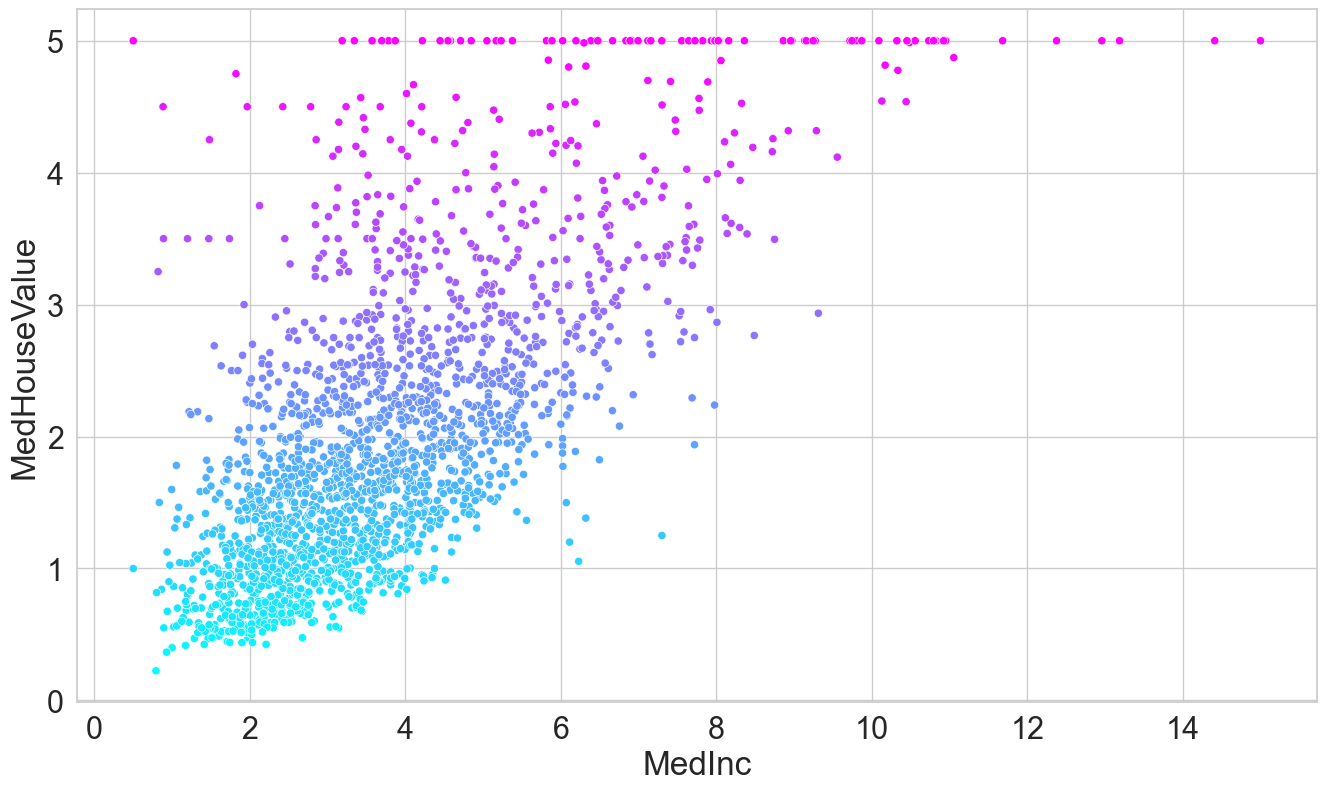

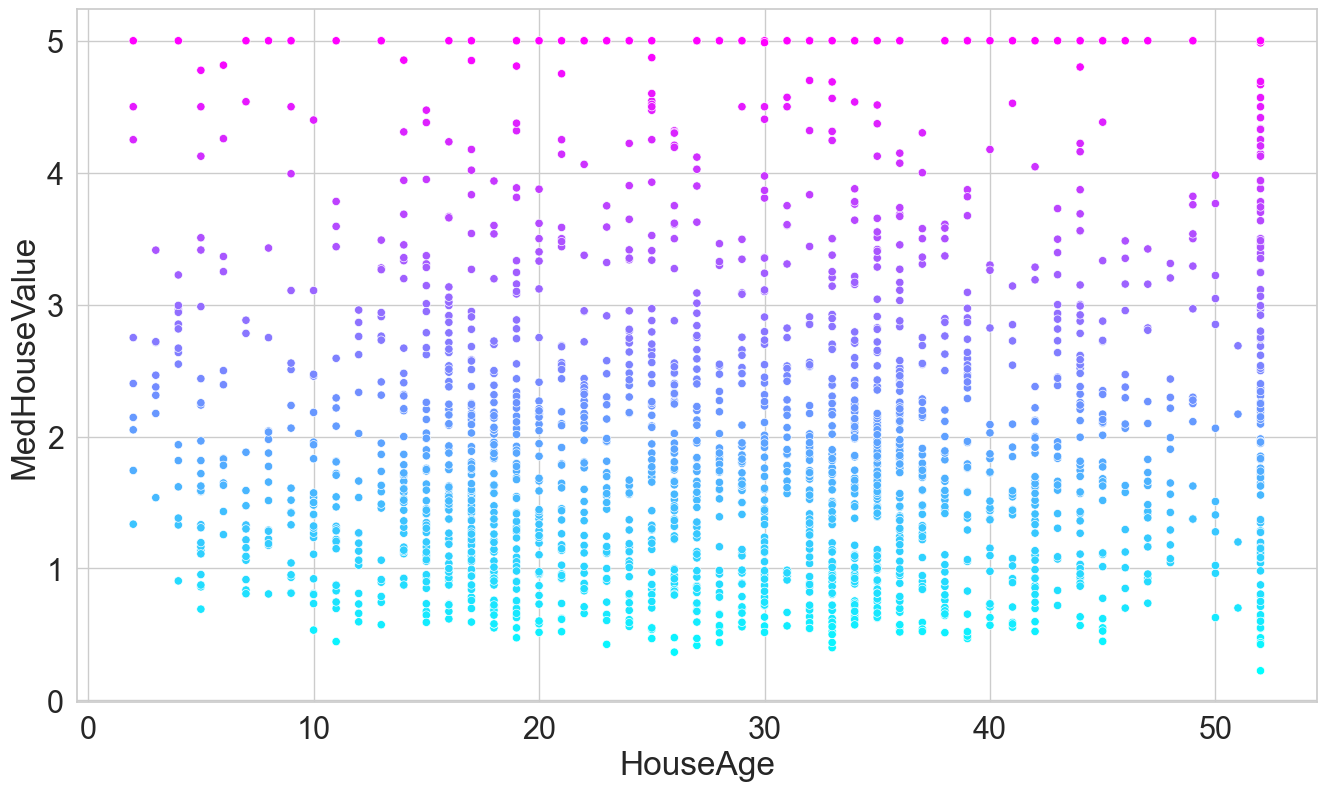

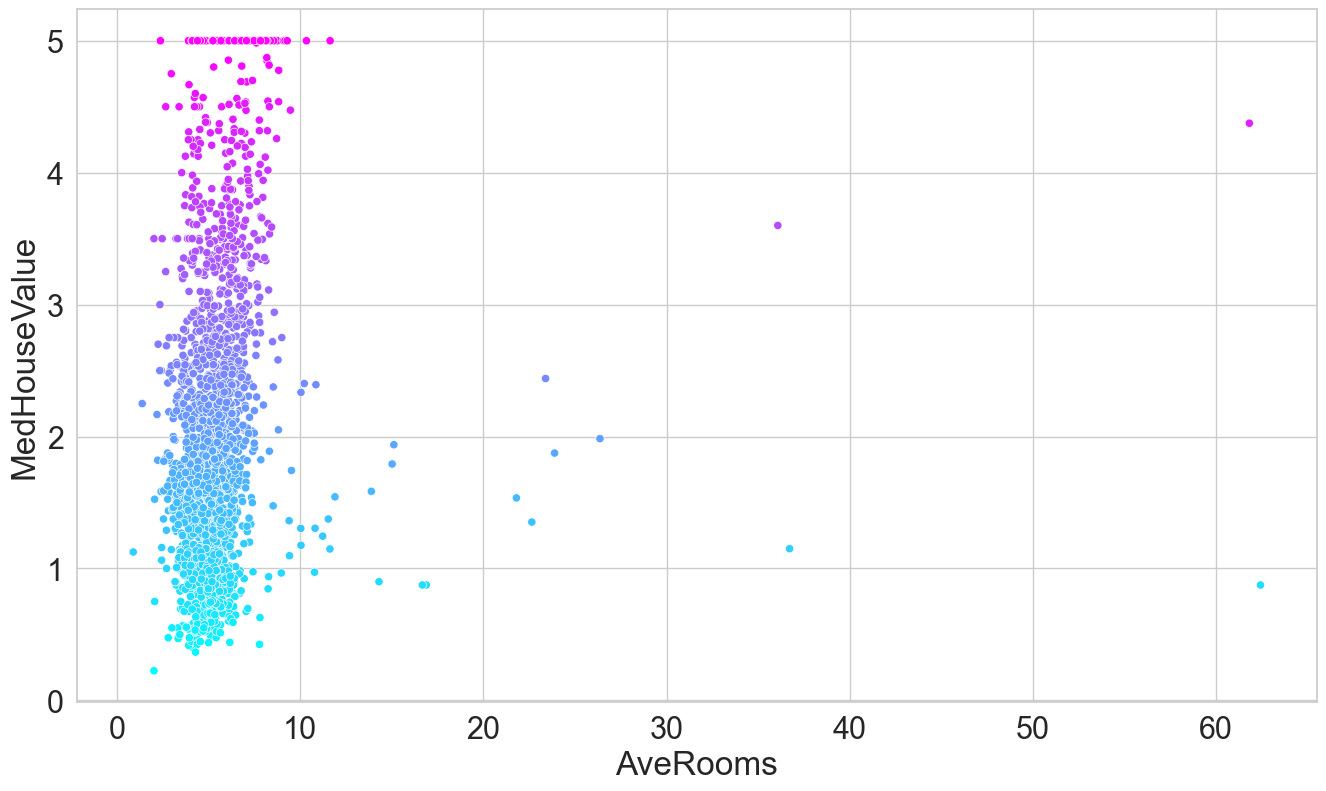

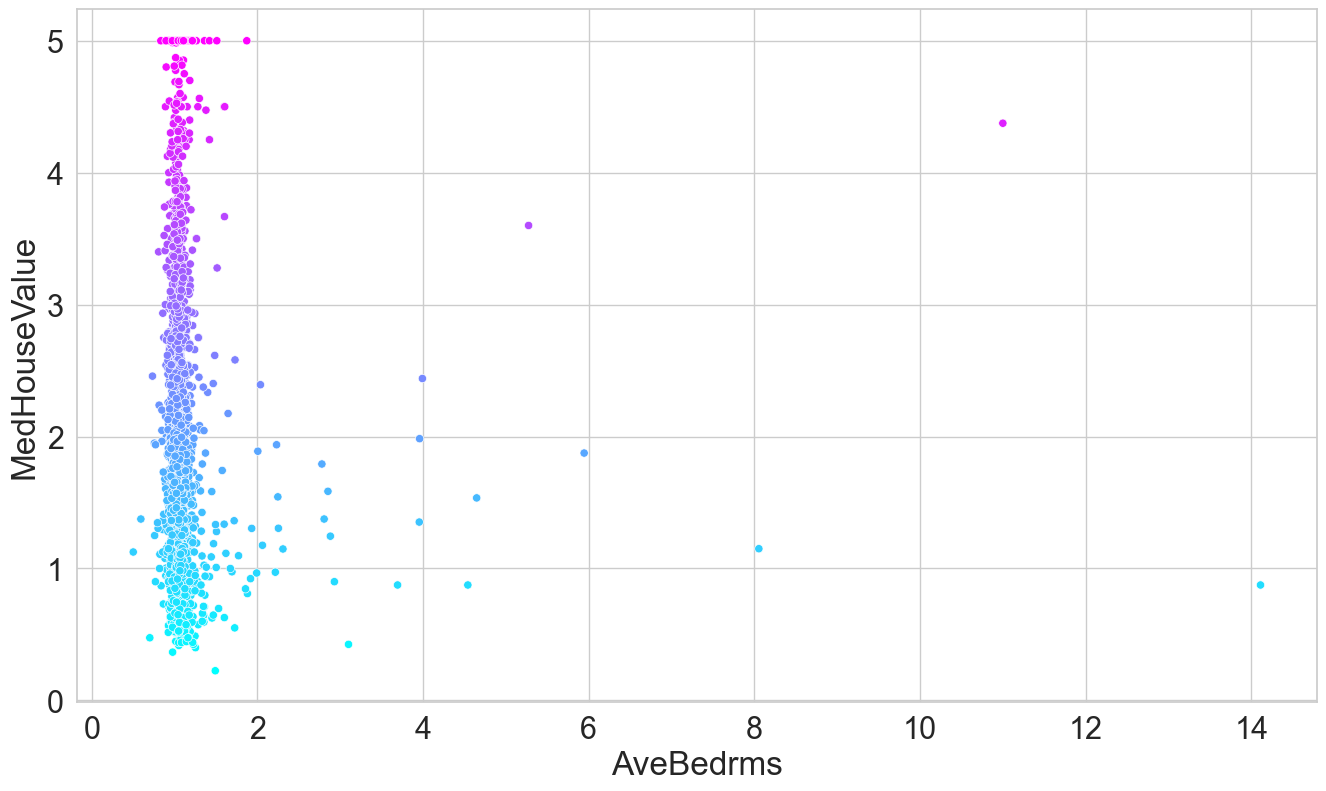

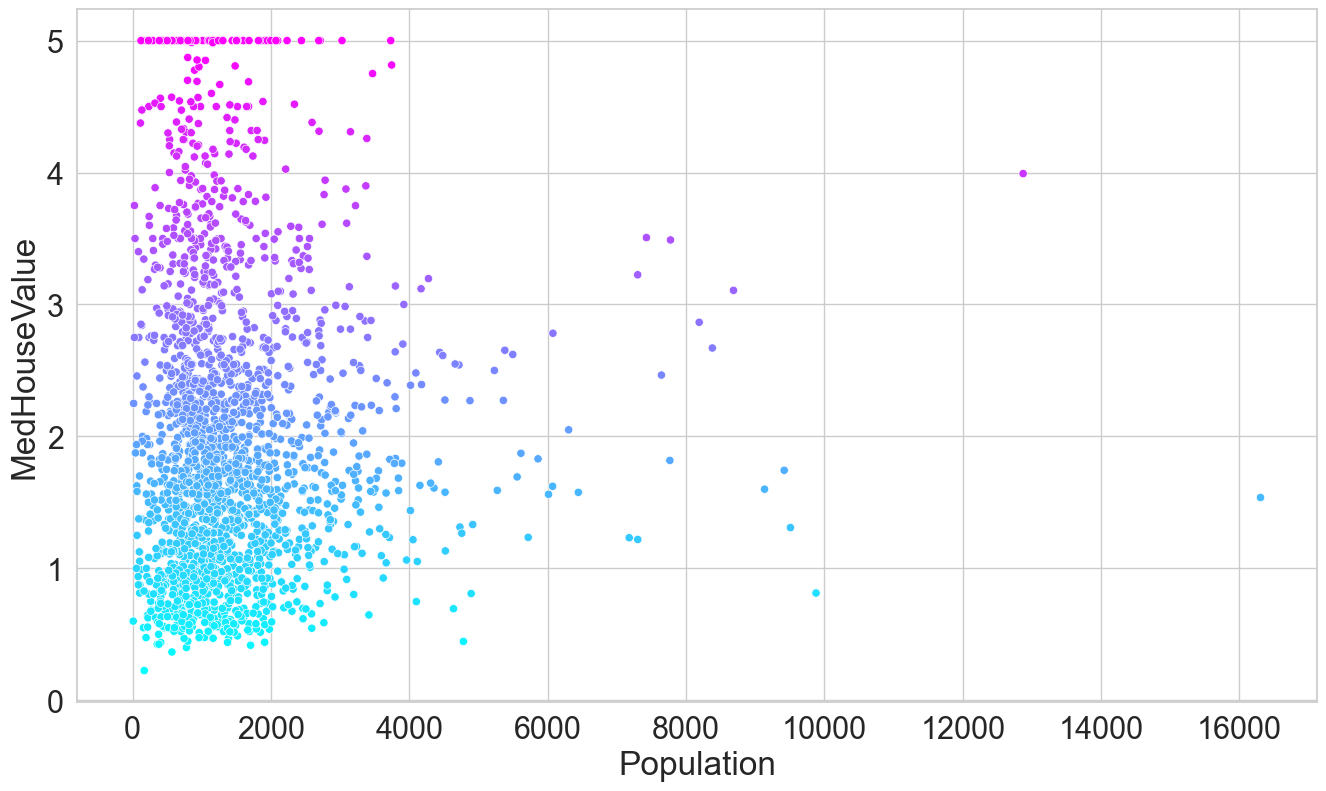

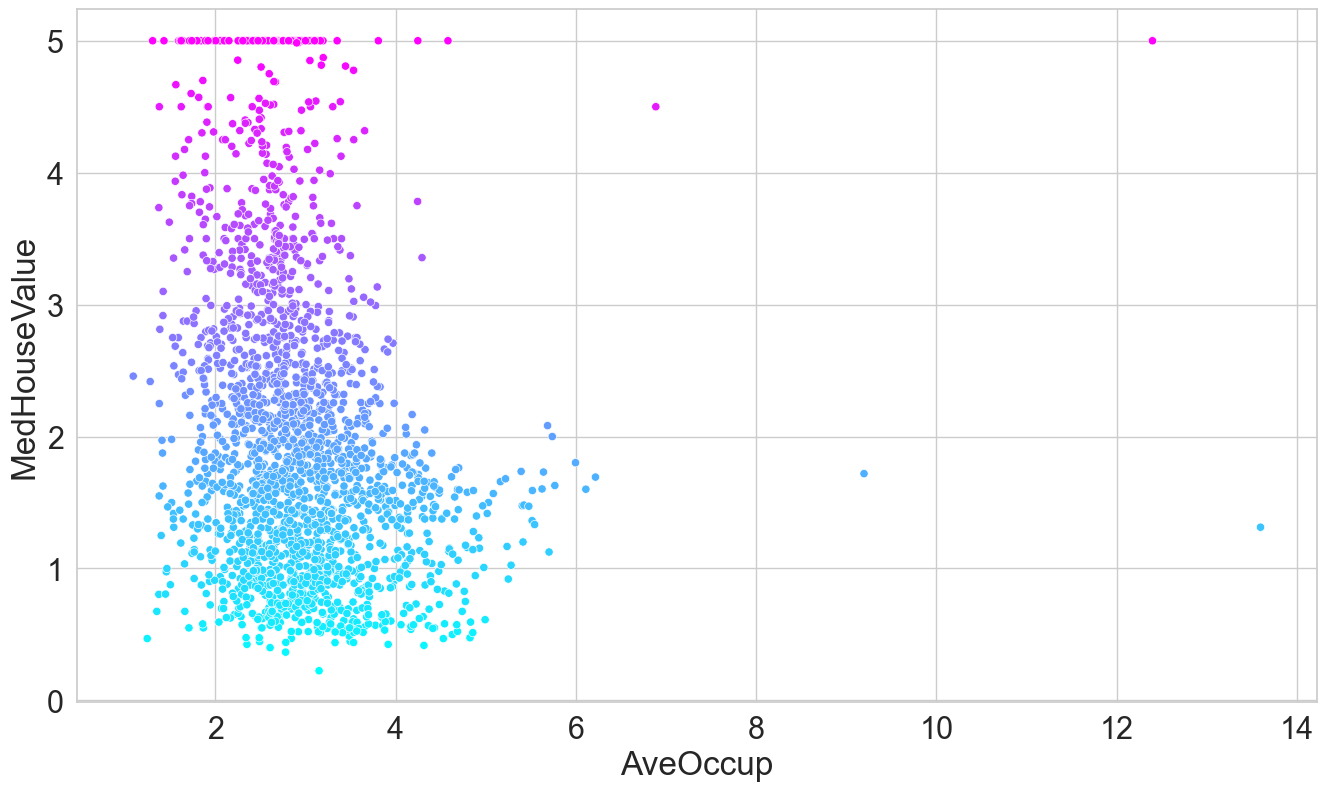

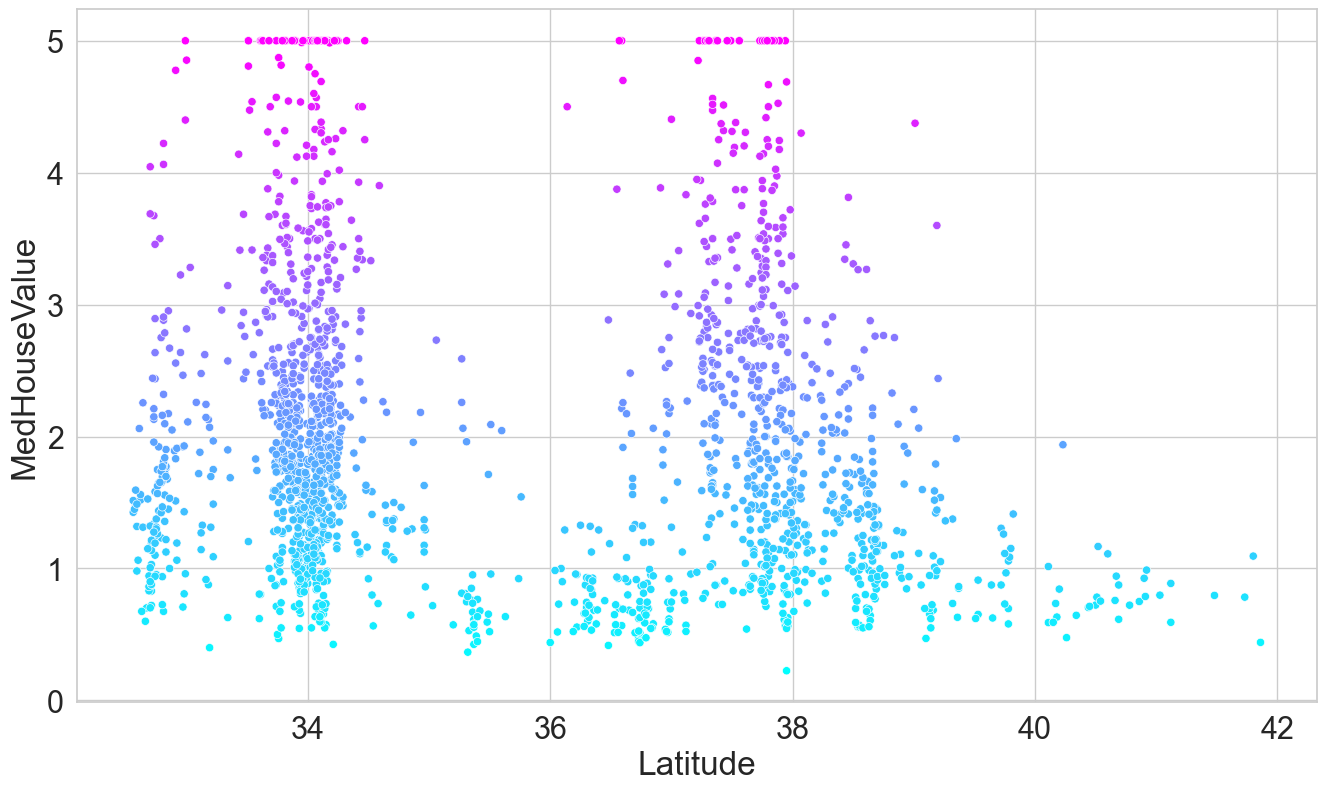

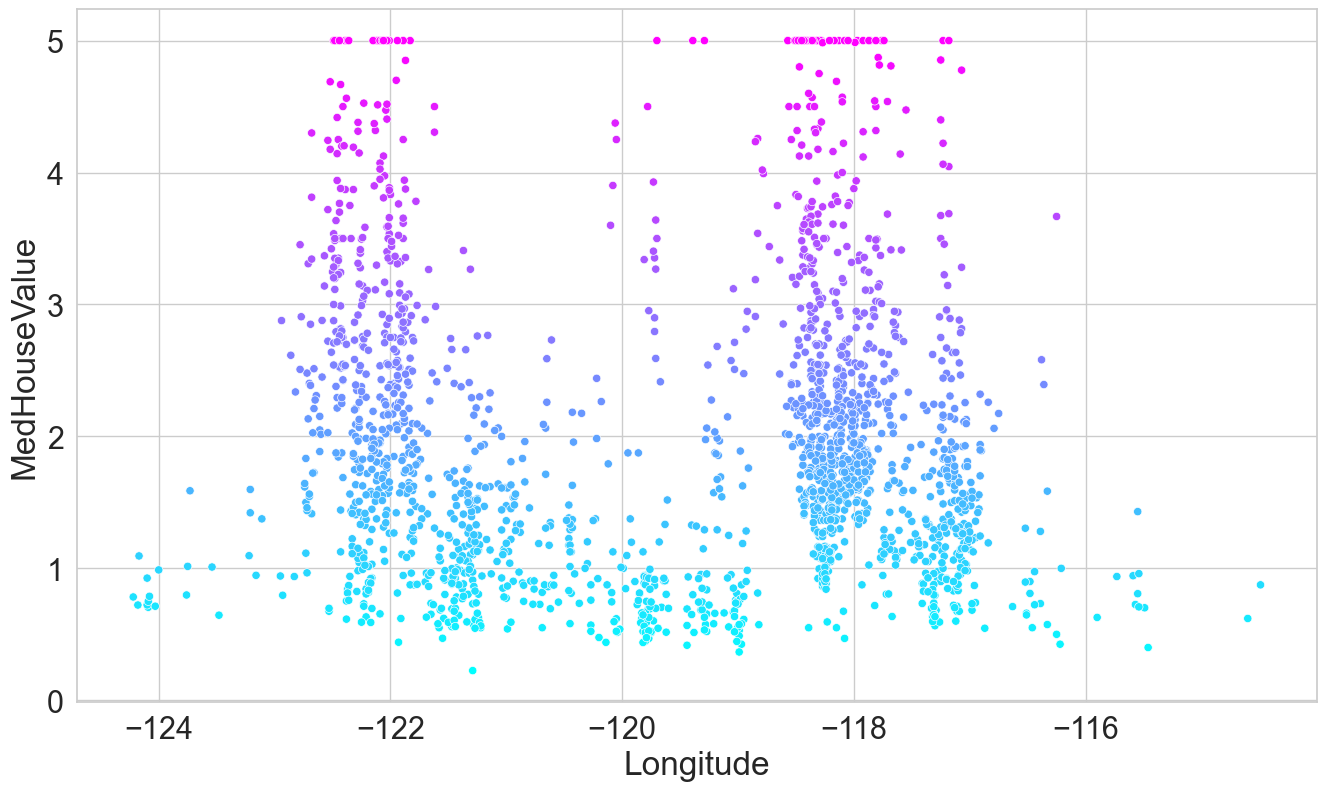

In [24]:
for feature in california.feature_names:
    plt.figure(figsize=(16,9))                  #Display the scatter plot with 16-inch-by-9-inch
    sns.scatterplot(
        data=sample_df,
        x=feature,
        y='MedHouseValue',
        hue='MedHouseValue',                #Determines the dot colors
        palette='cool',
        legend=False
    )

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    california.data,
    california.target,
    random_state=11
)

In [27]:
X_train.shape

(15480, 8)

In [28]:
X_test.shape

(5160, 8)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
linear_regression = LinearRegression()

In [31]:
linear_regression.fit(X=X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
for i, name in enumerate(california.feature_names):
    print(f'{name:>10}: {linear_regression.coef_[i]}')          #Coeficiente para cada atributo

    MedInc: 0.43770302153822016
  HouseAge: 0.009216834565797695
  AveRooms: -0.1073252663736094
 AveBedrms: 0.6117133073918101
Population: -5.756822009296558e-06
  AveOccup: -0.0033845664657163226
  Latitude: -0.4194818609649083
 Longitude: -0.43377133498740217


In [ ]:
#For positive coefficients, the median house value increases as the feature value increeases
#For negative coefficients, the median house value decreases as the feature value increases
#For population, the coefficient's value is close to zero, so a block group's population apparently has little effect the median house value

In [33]:
#Testing the model by calling the estimator's predict method  with the test samples as an argument

In [34]:
predicted = linear_regression.predict(X_test)           #Array of predictions

In [36]:
expected = y_test                                       #Array of expected values

In [37]:
predicted[:5]           #Show the first five predictions

array([1.25396876, 2.34693107, 2.03794745, 1.8701254 , 2.53608339])

In [38]:
expected[:5]

array([0.762, 1.732, 1.125, 1.37 , 1.856])

In [39]:
#Visualizing the Expected vs Predicted values

In [40]:
df = pd.DataFrame()

In [41]:
df['Expected'] = pd.Series(expected)
df['Predicted'] = pd.Series(predicted)

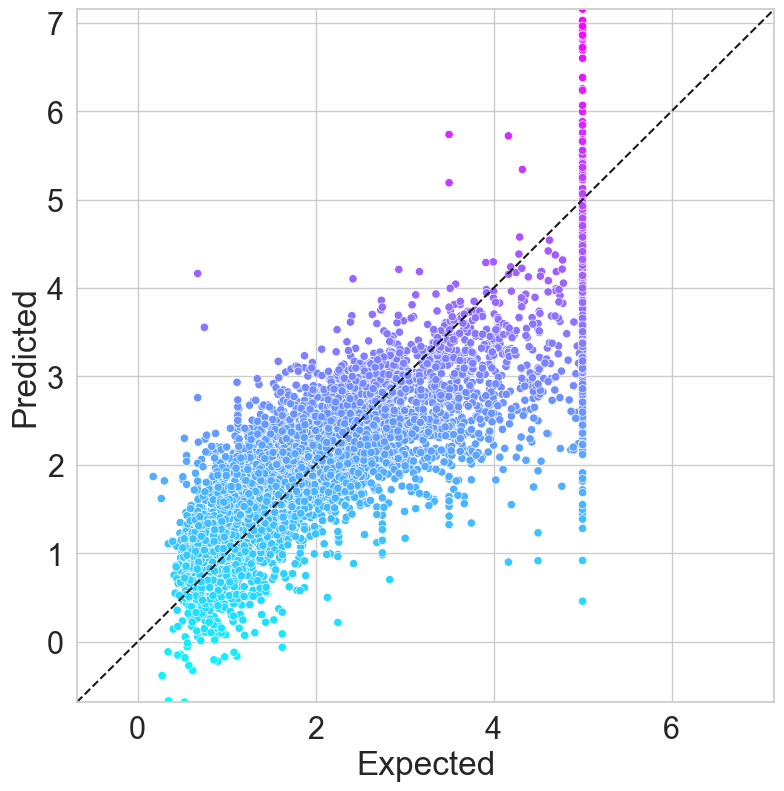

In [45]:
figure = plt.figure(figsize=(9,9))
axes = sns.scatterplot(data=df, x='Expected', y='Predicted', hue='Predicted', palette='cool', legend=False)
#Set the limits
start = min(expected.min(), predicted.min())
end = max(expected.max(), predicted.max())
axes.set_xlim(start, end)
axes.set_ylim(start, end)
line = plt.plot([start, end], [start, end], 'k--')          #k--indicates de line style and represents the color black in dashed line

In [46]:
#Regression Model Metrics

In [47]:
from sklearn import metrics

In [48]:
metrics.r2_score(expected, predicted)       #Return a range 0-1, which 1 indicates that the estimator perfectly predicts the dependent variable's value

0.6008983115964331

In [49]:
metrics.mean_squared_error(expected, predicted)         #a value closest to 0 best fits your data

0.535014977444912

In [50]:
#Closing the best model

In [51]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

In [52]:
estimators = {
    'Linear Regression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

In [53]:
estimators

{'Linear Regression': LinearRegression(),
 'ElasticNet': ElasticNet(),
 'Lasso': Lasso(),
 'Ridge': Ridge()}

In [54]:
from sklearn.model_selection import KFold, cross_val_score

In [57]:
for estimator_name, estimator_object  in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object, X=california.data, y=california.target, cv=kfold, scoring='r2')    #scoring = r2 -> the function should report the R2 scores for each fold
    print(f'{estimator_name:>16}: mean of r2 scores= {scores.mean():.3f}')

Linear Regression: mean of r2 scores= 0.599
      ElasticNet: mean of r2 scores= 0.423
           Lasso: mean of r2 scores= 0.285
           Ridge: mean of r2 scores= 0.599


In [58]:
#cross_val_score returns a 1.0 for the best